# Hess Corporation: A Comprehensive Valuation & M&A Analysis
## In the Context of Chevron's $53B Acquisition

*An investment banking analysis combining trading comps, precedent transactions, DCF, LBO, and accretion/dilution methodologies — built with live market data.*

---

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from dotenv import load_dotenv

load_dotenv()

from config.constants import (HESS_FINANCIALS, HESS_UNAFFECTED_PRICE, DEAL_TERMS,
    CVX_FINANCIALS, PRECEDENT_TRANSACTIONS, PEER_TICKERS, HESS_PRODUCTION_HISTORY,
    DAMODARAN_EP, SYNERGY_SCENARIOS, PEER_PRODUCTION_KBOEPD)
from utils.styling import (setup_ib_style, IB_COLORS, plot_football_field,
    plot_sensitivity_heatmap, plot_waterfall, plot_tornado, plot_monte_carlo_hist,
    plot_comps_scatter, plot_bar_chart, plot_grouped_bar, plot_area_chart,
    plot_oil_price_chart, format_comps_table)
from utils.data_fetch import fetch_peer_comps, fetch_commodity_prices, fetch_fred_data, validate_tickers

setup_ib_style()
np.random.seed(42)

print("✓ All imports loaded successfully")

✓ All imports loaded successfully


In [2]:
# Validate and fetch peer data
valid_tickers, failed_tickers = validate_tickers(PEER_TICKERS)
print(f"✓ {len(valid_tickers)}/{len(PEER_TICKERS)} peers available")
if failed_tickers:
    print(f"  Skipped: {failed_tickers}")

peer_data = fetch_peer_comps(valid_tickers)
commodities = fetch_commodity_prices()
fred_data = fetch_fred_data(os.getenv('FRED_API_KEY'))

print(f"✓ Commodities: {list(commodities.keys())}")
print(f"✓ FRED series: {list(fred_data.keys())}")

✓ 10/10 peers available


[fetch_peer_comps] Fetched 10/10 peers


[fetch_commodity_prices] Fetched: WTI, Brent, NatGas, Treasury_10Y, XLE, XOP, SP500


[fetch_fred_data] Fetched series: BAMLH0A0HYM2, DHHNGSP, DFF, T10Y2Y
✓ Commodities: ['WTI', 'Brent', 'NatGas', 'Treasury_10Y', 'XLE', 'XOP', 'SP500']
✓ FRED series: ['BAMLH0A0HYM2', 'DHHNGSP', 'DFF', 'T10Y2Y']


---

## 1. Executive Summary

On **October 23, 2023**, Chevron Corporation (CVX) announced an all-stock acquisition of Hess Corporation for approximately **$53 billion** in equity value (~$60B enterprise value), offering **1.025 CVX shares per HES share** — implying a price of ~$171/share and a **~10% premium** to Hess's unaffected closing price of $155.39.

**Key Deal Highlights:**
- **Strategic rationale:** Chevron gains Hess's 30% interest in Guyana's Stabroek Block — one of the largest oil discoveries in the past decade with ~11 billion BOE of recoverable resources
- **Structure:** All-stock merger, no cash component
- **Regulatory path:** FTC clearance obtained; deal closed October 1, 2024
- **Key risk:** ExxonMobil's preemptive rights claim over Hess's Guyana interest, resolved via ICC arbitration in September 2024 in favor of Chevron/Hess

### Valuation Summary

The table and football field chart below synthesize our findings across five valuation methodologies:

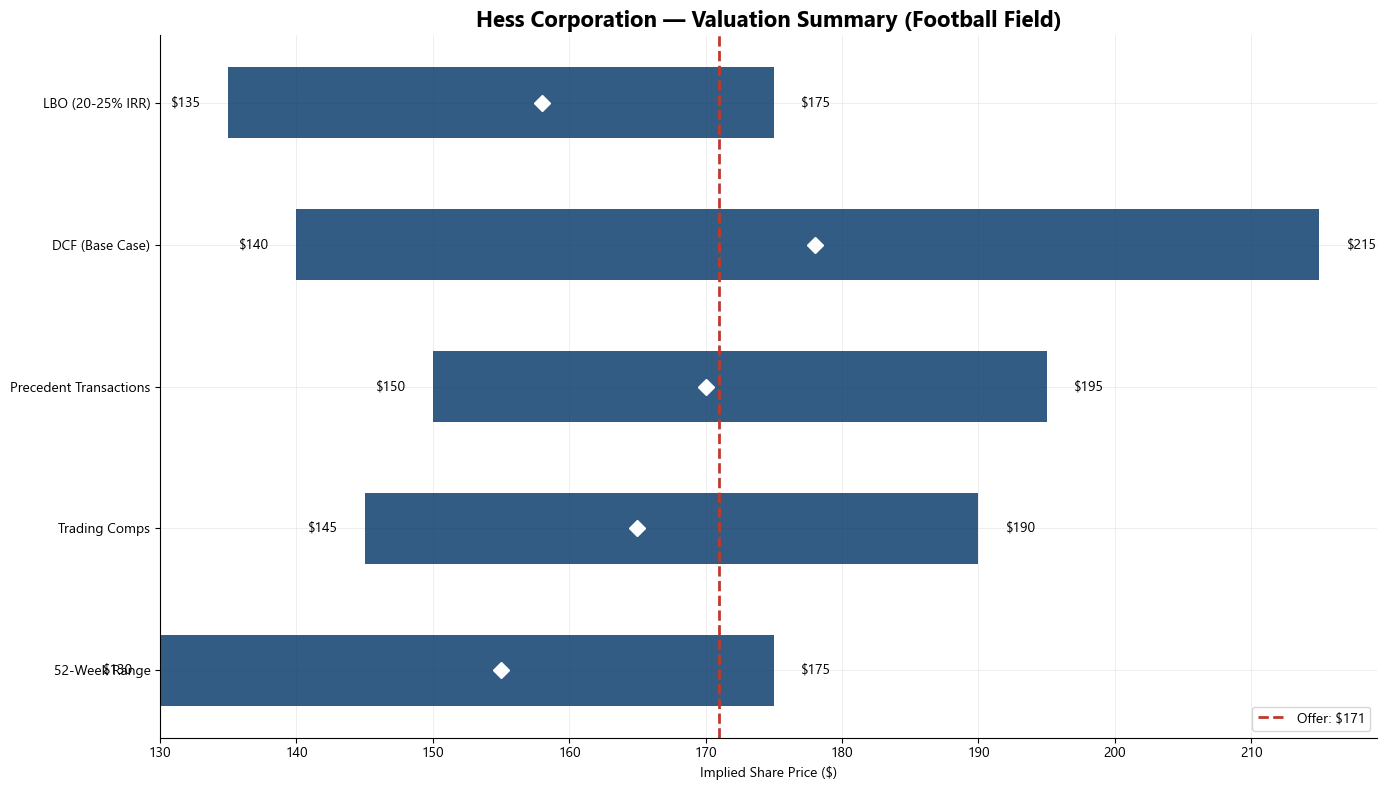

In [3]:
# PLACEHOLDER — Updated in Section 8 after all analyses are computed
placeholder_valuations = {
    '52-Week Range': (130, 155, 175),
    'Trading Comps': (145, 165, 190),
    'Precedent Transactions': (150, 170, 195),
    'DCF (Base Case)': (140, 178, 215),
    'LBO (20-25% IRR)': (135, 158, 175),
}

fig = plot_football_field(placeholder_valuations, DEAL_TERMS['implied_price'],
                          'Hess Corporation — Valuation Summary (Football Field)')
plt.show()

> **Note:** The football field chart above is a preliminary summary. Each methodology is detailed in subsequent sections. The final comprehensive football field appears in Section 8.

---

## 2. Company & Industry Overview

### What We're Doing
Providing context on Hess Corporation, its key assets, and the energy sector dynamics that drove this deal.

### Hess Corporation Profile

Hess Corporation (NYSE: HES, now delisted) was a global exploration and production (E&P) company headquartered in New York City. Founded in 1933 by Leon Hess, the company operated primarily as an upstream oil and gas producer with assets spanning:

- **Guyana (Stabroek Block):** 30% working interest (operator: ExxonMobil). The crown jewel — one of the largest offshore oil discoveries in the past decade with estimated recoverable resources of ~11 billion BOE. Production ramped from zero in late 2019 to ~640 KBOEPD gross by 2027 (Hess net: ~195 KBOEPD in 2023).
- **Bakken (North Dakota):** ~170,000 net acres in the Williston Basin, producing ~190 KBOEPD
- **Gulf of Mexico:** Deepwater assets with ~35 KBOEPD
- **Southeast Asia (Malaysia/JDA):** ~30 KBOEPD of natural gas production

### Why Chevron Wants Hess

The Stabroek Block is the strategic prize. Guyana offers:
- **Low-cost barrels:** ~$35/bbl breakeven — among the lowest globally
- **Decades of production growth:** Multiple FPSOs planned, with production expected to exceed 1.2M BOEPD gross by 2030
- **Portfolio diversification:** Reduces Chevron's Permian concentration
- **Resource optionality:** Continued exploration upside in the 6.6 million acre block


### The Guyana Stabroek Block — Why It Matters

The Stabroek Block has transformed Hess from a mid-cap E&P into a strategic acquisition target. Key facts:

| Metric | Value |
|--------|-------|
| Block size | 6.6 million acres |
| Operator | ExxonMobil (45% WI) |
| Hess interest | 30% working interest |
| CNOOC interest | 25% working interest |
| Discovered resources | ~11 billion BOE |
| Current FPSOs | 3 (Liza Phase 1, Liza Phase 2, Payara) |
| Planned FPSOs | 6+ total by 2030 |
| Gross production (2024) | ~640 KBOEPD |
| Breakeven cost | ~$35/bbl |

The block's significance cannot be overstated: it represents the largest discovery of conventional oil resources in the past decade and one of the lowest-cost producing basins globally. For Chevron, acquiring Hess's 30% stake provides exposure to this growth without the operational burden of being the operator.

### The Exxon Arbitration Risk

ExxonMobil, as operator of the Stabroek Block, claimed a right of first refusal over Hess's interest, arguing that the Chevron merger effectively constituted a "change of control" that triggered preemptive rights under the joint operating agreement. This claim was heard by an ICC arbitration tribunal, which ruled in **September 2024 in favor of Chevron/Hess**, clearing the final major obstacle to deal completion.


### Energy Sector Context: The E&P Consolidation Wave

The Chevron/Hess deal did not happen in isolation. 2023-2024 saw the largest wave of E&P M&A activity since the early 2000s, driven by:

1. **Capital discipline era:** Post-2020 crash, E&P companies prioritized returns over growth — creating cash-rich balance sheets
2. **Inventory concerns:** Permian Basin tier-1 drilling inventory declining, pushing companies to acquire rather than explore
3. **Shareholder pressure:** Investors rewarded scale, diversification, and operational efficiency
4. **Favorable commodity prices:** WTI sustained above $70/bbl provided deal economics

Over $200 billion in E&P deals were announced in 2023-2024, including ExxonMobil/Pioneer ($64.5B), ConocoPhillips/Marathon Oil ($22.5B), and Diamondback/Endeavor ($26B).

### Key Assumptions
- Hess production figures from 10-K filings (FY2022-2023)
- Guyana resource estimates from operator (ExxonMobil) public disclosures
- Commodity prices from Yahoo Finance (front-month futures, not spot)

### Limitations
- Production forecasts beyond 2024 are estimates and subject to operational/regulatory risk
- Guyana resource estimates may change with further exploration/appraisal


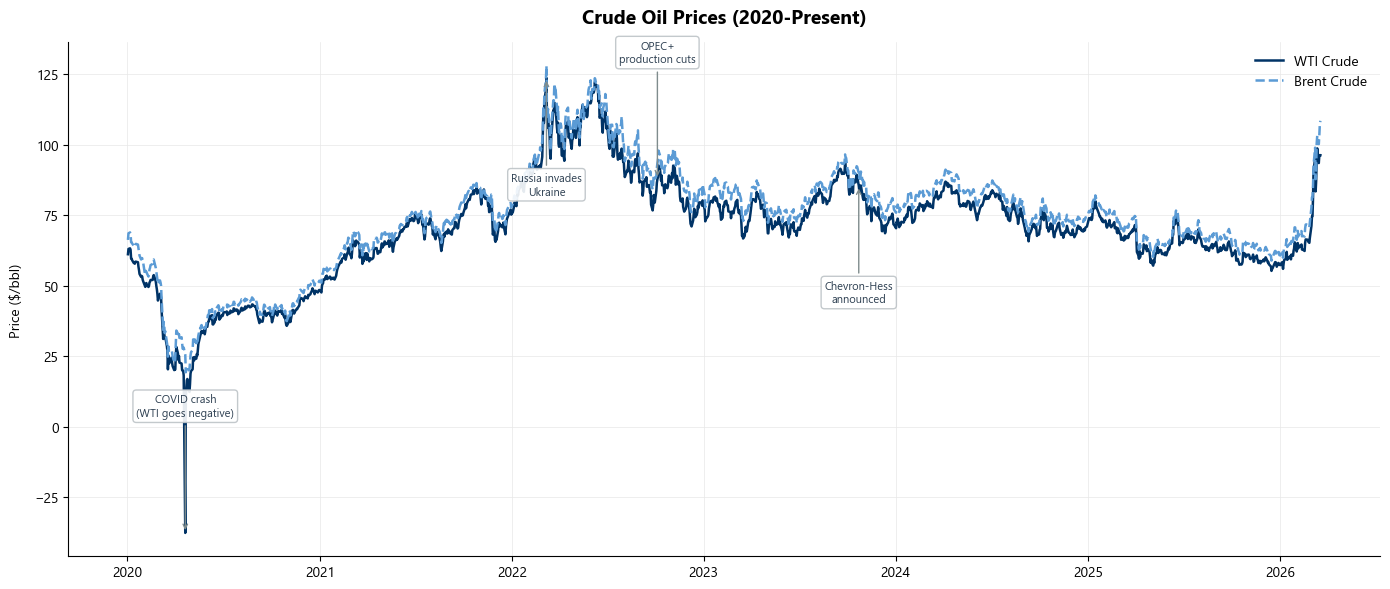

In [4]:
# Oil Price History (2020-Present) with Key Events
wti_df = commodities.get('WTI')
brent_df = commodities.get('Brent')

def _to_series(df):
    if df is None:
        return None
    if hasattr(df, 'columns'):
        # Handle MultiIndex columns from newer yfinance
        if isinstance(df.columns, pd.MultiIndex):
            close_cols = [c for c in df.columns if 'Close' in str(c)]
            s = df[close_cols[0]] if close_cols else df.iloc[:, 0]
        elif 'Close' in df.columns:
            s = df['Close']
        else:
            s = df.iloc[:, 0]
        return s.squeeze().dropna()
    return df.dropna()

wti = _to_series(wti_df)
brent = _to_series(brent_df)

if wti is not None and brent is not None:
    events = {
        '2020-04-20': 'COVID crash\n(WTI goes negative)',
        '2022-03-08': 'Russia invades\nUkraine',
        '2022-10-05': 'OPEC+\nproduction cuts',
        '2023-10-23': 'Chevron-Hess\nannounced',
    }
    fig = plot_oil_price_chart(wti, brent, events,
                               'Crude Oil Prices (2020-Present)')
    plt.show()
else:
    print('\u26a0 Oil price data unavailable')


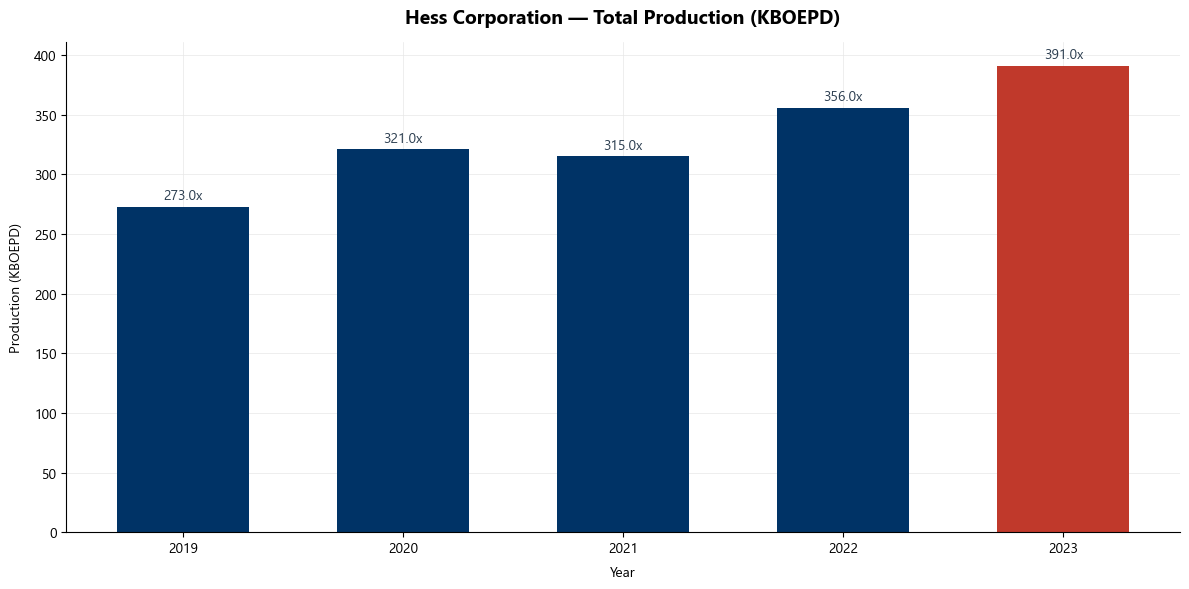

In [5]:
# Hess Production Growth (2019-2023)
years = list(HESS_PRODUCTION_HISTORY.keys())
production = list(HESS_PRODUCTION_HISTORY.values())

fig = plot_bar_chart(
    labels=[str(y) for y in years],
    values=production,
    title='Hess Corporation — Total Production (KBOEPD)',
    xlabel='Year',
    ylabel='Production (KBOEPD)',
    highlight_idx=len(years)-1  # Highlight most recent year
)
plt.show()


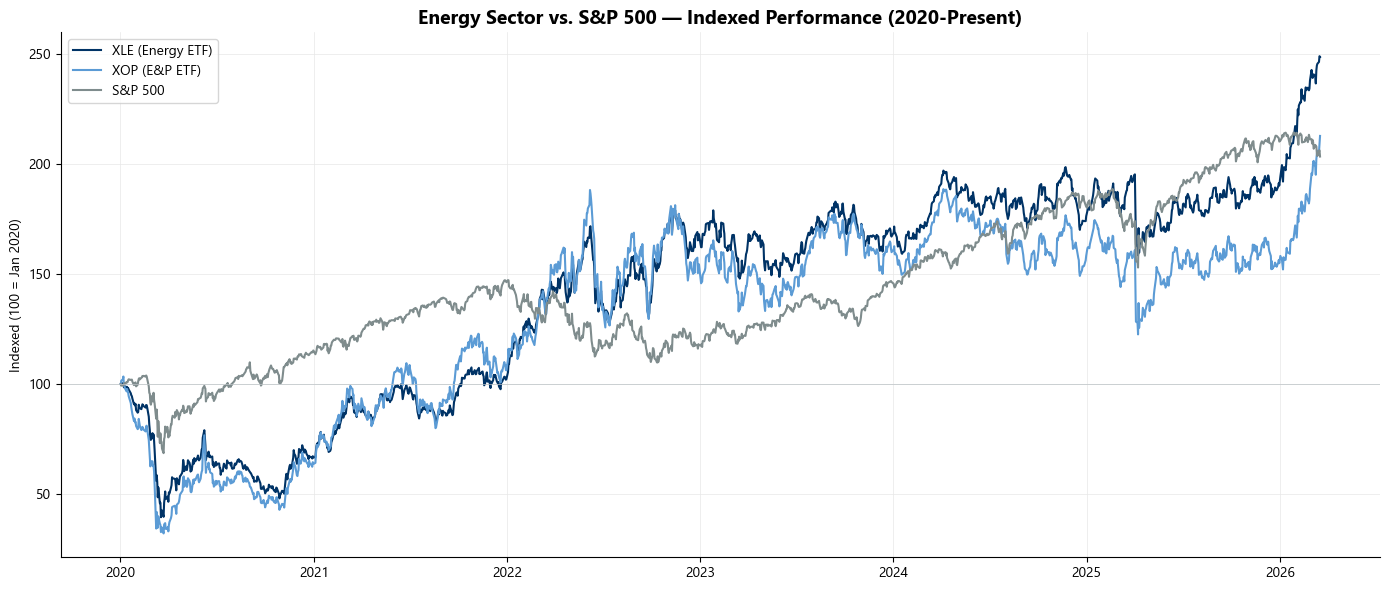

In [6]:
# E&P Sector Performance vs S&P 500 (Normalized to 100)
xle = commodities.get('XLE')
xop = commodities.get('XOP')
sp500 = commodities.get('SP500')

if xle is not None and xop is not None and sp500 is not None:
    fig, ax = plt.subplots(figsize=(14, 6))

    # Normalize to 100 at start date
    for series, name, color in [(xle, 'XLE (Energy ETF)', IB_COLORS['navy']),
                                 (xop, 'XOP (E&P ETF)', IB_COLORS['steel_blue']),
                                 (sp500, 'S&P 500', IB_COLORS['gray'])]:
        # Handle both single and multi-level columns from yfinance
        if hasattr(series, 'columns'):
            if 'Close' in series.columns:
                prices = series['Close']
            else:
                prices = series.iloc[:, 0]
        else:
            prices = series
        normalized = (prices / prices.iloc[0]) * 100
        ax.plot(normalized.index, normalized.values, label=name, color=color, linewidth=1.5)

    ax.axhline(100, color=IB_COLORS['light_gray'], linestyle='-', linewidth=0.5)
    ax.set_title('Energy Sector vs. S&P 500 — Indexed Performance (2020-Present)',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Indexed (100 = Jan 2020)')
    ax.legend(loc='upper left')
    ax.set_xlabel('')
    plt.tight_layout()
    plt.show()
else:
    print("\u26a0 ETF/index data unavailable")


### So What

The charts above illustrate two key dynamics:

1. **Energy has outperformed:** After the 2020 COVID crash, the energy sector massively outperformed the broader market (2022-2023), driven by supply constraints, OPEC+ discipline, and Russia-Ukraine supply disruption. This created the war chests that funded the M&A wave.

2. **Hess's production story is Guyana:** The 43% production growth from 2019 to 2023 (273 → 391 KBOEPD) is almost entirely driven by the Stabroek Block ramp. This trajectory — and the 2030+ growth runway — is what Chevron is paying for.

---


---

## 3. Trading Comps Analysis

### What We're Doing
Trading comparables (or "public market comps") estimates Hess's intrinsic value by benchmarking it against how the market prices similar, publicly traded E&P companies. The core premise: companies with similar assets, growth profiles, and risk should trade at similar multiples of earnings, cash flow, or enterprise value.

### Peer Group Selection

We selected 10 publicly traded E&P and integrated oil companies as the peer universe. Tickers were chosen to capture the full spectrum of Hess comparables — from supermajors to pure-play shale operators.

| Ticker | Company | Rationale |
|--------|---------|-----------|
| CVX | Chevron Corporation | Integrated supermajor; acquirer in this deal |
| XOM | ExxonMobil | Integrated supermajor; Guyana co-venturer (operator) |
| COP | ConocoPhillips | Large independent E&P; diversified global portfolio |
| EOG | EOG Resources | High-quality pure-play U.S. shale; premium-rated comps |
| DVN | Devon Energy | Diversified U.S. onshore E&P; Williston exposure |
| FANG | Diamondback Energy | Permian pure-play; high-efficiency benchmark |
| OXY | Occidental Petroleum | Diversified E&P + chemical; Permian heavy |
| APA | APA Corporation | Diversified international E&P including North Sea |
| CTRA | Coterra Energy | Diversified oil & gas; Permian + Appalachian |
| EQT | EQT Corporation | Largest U.S. natural gas producer; Appalachian Basin |

### Key Assumptions
- Market data sourced from Yahoo Finance (as of data fetch date)
- EV/EBITDA is the primary multiple for E&P comparables (less distorted by D&A differences than P/E)
- Hess metrics calculated at **unaffected price of $155.39** (pre-announcement close)
- EV/BOEPD normalizes for production scale; useful for Guyana premium analysis

### Limitations
- Peer multiples reflect *current* market conditions, not the deal announcement date (Oct 2023)
- EQT is gas-weighted — its multiples may not be directly comparable to oil-heavy Hess
- CVX and XOM are integrated majors with downstream businesses, depressing their EV/EBITDA vs. pure-play E&Ps
- Trading comps do not capture Hess's Guyana *growth optionality* premium


In [7]:
# -- Section 3: Build Trading Comps Table --

fy23 = HESS_FINANCIALS['FY2023']

# Hess metrics at unaffected price
hess_market_cap = HESS_UNAFFECTED_PRICE * fy23['shares_outstanding_M']   # $M
hess_ev = hess_market_cap + fy23['total_debt'] - fy23['cash']             # $M

hess_ev_ebitda  = hess_ev / fy23['ebitda']
hess_ev_revenue = hess_ev / fy23['revenue']
hess_pe         = HESS_UNAFFECTED_PRICE / (fy23['net_income'] / fy23['shares_outstanding_M'])
# EV ($M) / production (KBOEPD) = $M/KBOEPD = $K/BOE/D
hess_ev_boepd_k = hess_ev / fy23['production_kboepd']

print(f"Hess Market Cap (unaffected): ${hess_market_cap/1000:.1f}B")
print(f"Hess EV (unaffected):          ${hess_ev/1000:.1f}B")
print(f"Hess EV/EBITDA:                {hess_ev_ebitda:.1f}x")
print(f"Hess EV/Revenue:               {hess_ev_revenue:.1f}x")
print(f"Hess P/E:                      {hess_pe:.1f}x")
print(f"Hess EV/BOEPD:                 ${hess_ev_boepd_k:.0f}K/BOE/D")

# -- Build peer comps rows --
# peer_data has ticker as the index (set_index in fetch_peer_comps)
rows = []
for ticker, row in peer_data.iterrows():
    prod = PEER_PRODUCTION_KBOEPD.get(ticker, None)
    ev_val = row.get('enterpriseValue')
    # EV (in $) / 1e6 -> $M; $M / KBOEPD = $K/BOE/D
    ev_boepd_k = (ev_val / 1e6 / prod) if (prod and ev_val) else None

    rows.append({
        'Company': row.get('shortName', ticker),
        'Ticker': ticker,
        'Market Cap ($B)': row.get('marketCap', 0) / 1e9,
        'EV ($B)': ev_val / 1e9 if ev_val else float('nan'),
        'EV/EBITDA': row.get('enterpriseToEbitda', float('nan')),
        'EV/Revenue': row.get('enterpriseToRevenue', float('nan')),
        'P/E': row.get('trailingPE', float('nan')),
        'EV/BOEPD ($K)': ev_boepd_k,
    })

# Hess row
rows.append({
    'Company': 'Hess Corporation',
    'Ticker': 'HES',
    'Market Cap ($B)': hess_market_cap / 1000,
    'EV ($B)': hess_ev / 1000,
    'EV/EBITDA': hess_ev_ebitda,
    'EV/Revenue': hess_ev_revenue,
    'P/E': hess_pe,
    'EV/BOEPD ($K)': hess_ev_boepd_k,
})

comps_df = pd.DataFrame(rows)
comps_df = comps_df.sort_values('EV ($B)', ascending=False).reset_index(drop=True)

print("Trading Comparables Table:")
display(format_comps_table(comps_df))

Hess Market Cap (unaffected): $47.6B
Hess EV (unaffected):          $54.1B
Hess EV/EBITDA:                10.5x
Hess EV/Revenue:               5.2x
Hess P/E:                      22.6x
Hess EV/BOEPD:                 $138K/BOE/D
Trading Comparables Table:


,Company,Ticker,Market Cap ($B),EV ($B),EV/EBITDA,EV/Revenue,P/E,EV/BOEPD ($K)
0,Exxon Mobil Corporation,XOM,$657,$704,11.8x,2.2x,23.5%,$190
1,Chevron Corporation,CVX,$397,$442,11.8x,2.4x,30.0%,$143
2,ConocoPhillips,COP,$151,$169,7.0x,2.8x,19.4x,99.2%
3,Occidental Petroleum Corporatio,OXY,57.6%,87.8%,7.8x,4.1x,43.2%,73.2%
4,"EOG Resources, Inc.",EOG,74.6%,79.5%,6.8x,3.5x,15.1x,83.7%
5,"Diamondback Energy, Inc.",FANG,53.5%,73.9%,7.1x,5.2x,33.1%,$161
6,Hess Corporation,HES,47.6%,54.1%,10.5x,5.2x,22.6%,$138
7,EQT Corporation,EQT,39.7%,51.1%,8.4x,6.2x,19.2x,98.2%
8,Devon Energy Corporation,DVN,29.9%,37.2%,5.0x,2.3x,11.5x,56.3%
9,Coterra Energy Inc.,CTRA,25.4%,29.3%,6.1x,4.2x,14.9x,45.8%


In [8]:
# ── Section 3: Statistical Summary & Implied Valuation ────────────────────────

# Peers only (exclude Hess row)
peers_only = comps_df[comps_df['Ticker'] != 'HES'].copy()

# Drop NaN EV/EBITDA rows for summary statistics
ev_ebitda_clean = peers_only['EV/EBITDA'].dropna()
ev_rev_clean    = peers_only['EV/Revenue'].dropna()
pe_clean        = peers_only['P/E'].dropna()

stats_df = pd.DataFrame({
    'Metric':      ['EV/EBITDA', 'EV/Revenue', 'P/E'],
    'Mean':        [ev_ebitda_clean.mean(), ev_rev_clean.mean(), pe_clean.mean()],
    'Median':      [ev_ebitda_clean.median(), ev_rev_clean.median(), pe_clean.median()],
    '25th Pctile': [ev_ebitda_clean.quantile(0.25), ev_rev_clean.quantile(0.25), pe_clean.quantile(0.25)],
    '75th Pctile': [ev_ebitda_clean.quantile(0.75), ev_rev_clean.quantile(0.75), pe_clean.quantile(0.75)],
})
print("── Peer Multiple Statistics ──")
display(stats_df.style.format({
    'Mean': '{:.1f}x', 'Median': '{:.1f}x',
    '25th Pctile': '{:.1f}x', '75th Pctile': '{:.1f}x'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', IB_COLORS['navy']),
                                  ('color', 'white'), ('font-weight', 'bold')]}
]))

# ── Implied share price from peer EV/EBITDA quartiles ─────────────────────────
net_debt   = fy23['total_debt'] - fy23['cash']                       # $M
shares     = fy23['shares_outstanding_M']                             # M shares
ebitda     = fy23['ebitda']                                           # $M

p25_mult   = ev_ebitda_clean.quantile(0.25)
med_mult   = ev_ebitda_clean.median()
p75_mult   = ev_ebitda_clean.quantile(0.75)

def _ev_to_price(multiple):
    implied_ev     = multiple * ebitda
    implied_equity = implied_ev - net_debt
    return implied_equity / shares

low_price  = _ev_to_price(p25_mult)
mid_price  = _ev_to_price(med_mult)
high_price = _ev_to_price(p75_mult)

# Store for football field (Task 12)
comps_valuation = (low_price, mid_price, high_price)

print(f"\n── Implied Share Price (EV/EBITDA comps) ──")
print(f"  25th pctile multiple ({p25_mult:.1f}x):  ${low_price:.2f}")
print(f"  Median multiple      ({med_mult:.1f}x):  ${mid_price:.2f}")
print(f"  75th pctile multiple ({p75_mult:.1f}x):  ${high_price:.2f}")
print(f"  Hess unaffected price:              ${HESS_UNAFFECTED_PRICE:.2f}")
print(f"  Chevron offer price:                ${DEAL_TERMS['implied_price']:.2f}")
print(f"\ncomps_valuation = ({low_price:.1f}, {mid_price:.1f}, {high_price:.1f})")


── Peer Multiple Statistics ──


,Metric,Mean,Median,25th Pctile,75th Pctile
0,EV/EBITDA,7.5x,7.1x,6.2x,8.2x
1,EV/Revenue,3.5x,3.2x,2.3x,4.2x
2,P/E,21.9x,19.3x,15.0x,28.3x



── Implied Share Price (EV/EBITDA comps) ──
  25th pctile multiple (6.2x):  $84.16
  Median multiple      (7.1x):  $97.78
  75th pctile multiple (8.2x):  $117.86
  Hess unaffected price:              $155.39
  Chevron offer price:                $171.00

comps_valuation = (84.2, 97.8, 117.9)


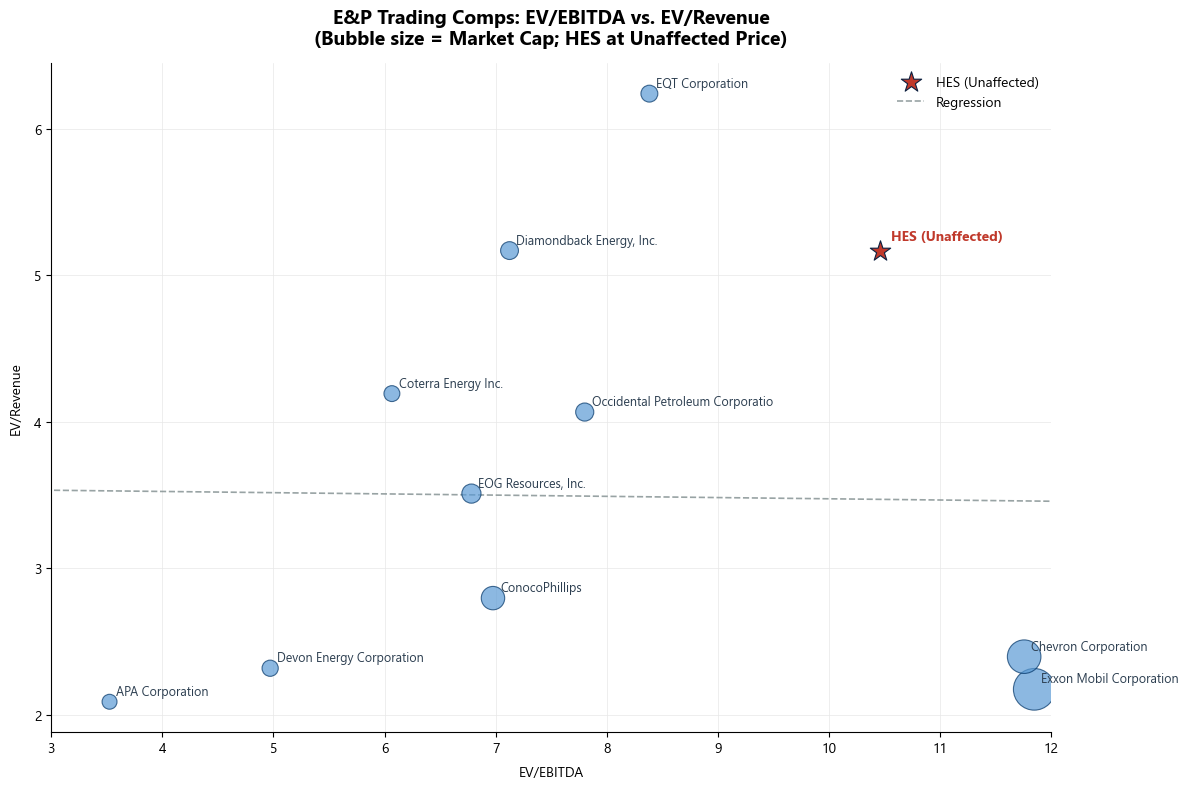

In [9]:
# ── Section 3: Comps Scatter / Bubble Chart ───────────────────────────────────

# Build scatter DataFrame from peers only (no Hess)
scatter_peers = peers_only[['Company', 'EV/EBITDA', 'EV/Revenue', 'Market Cap ($B)']].dropna().copy()
scatter_peers = scatter_peers.rename(columns={'Company': 'Name'})

# Hess point: (x=EV/EBITDA, y=EV/Revenue, size=MarketCap $B, label)
hess_point = (
    hess_ev_ebitda,
    hess_ev_revenue,
    hess_market_cap / 1000,
    'HES (Unaffected)'
)

fig = plot_comps_scatter(
    peer_data_df=scatter_peers,
    hess_point=hess_point,
    x_col='EV/EBITDA',
    y_col='EV/Revenue',
    size_col='Market Cap ($B)',
    title='E&P Trading Comps: EV/EBITDA vs. EV/Revenue\n(Bubble size = Market Cap; HES at Unaffected Price)',
)
plt.show()


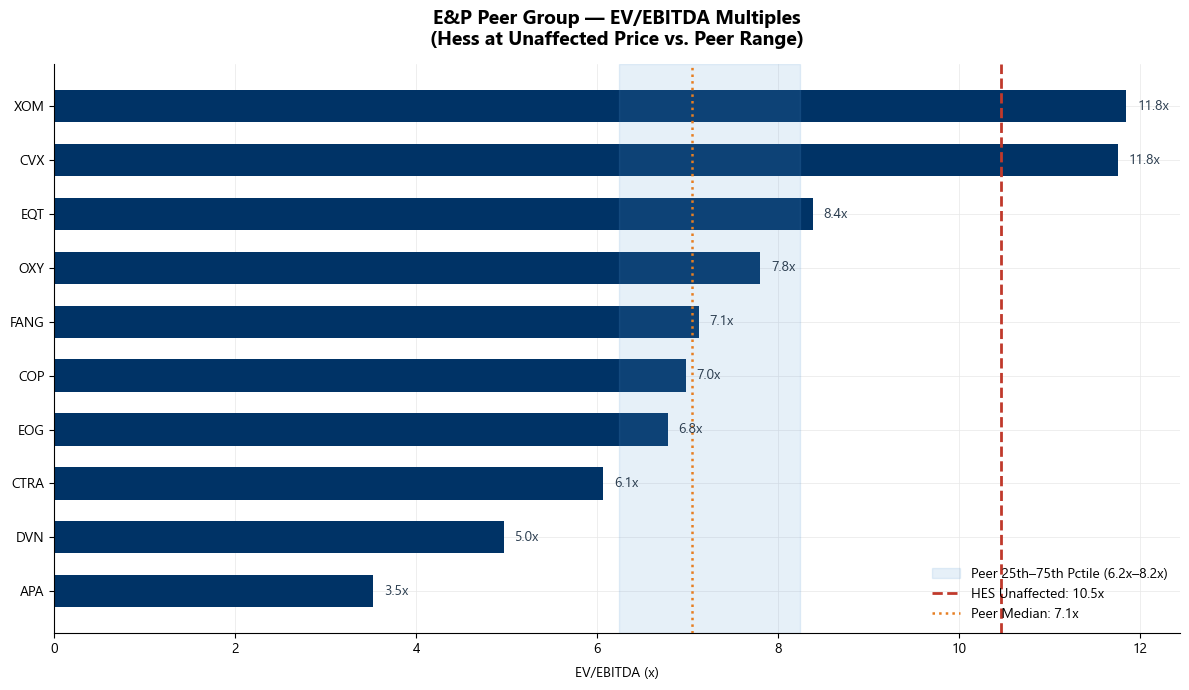

In [10]:
# ── Section 3: EV/EBITDA Bar Chart with Peer Range ────────────────────────────

# Sort peers by EV/EBITDA (ascending for horizontal chart readability)
bar_df = peers_only[['Ticker', 'EV/EBITDA']].dropna().sort_values('EV/EBITDA')

fig, ax = plt.subplots(figsize=(12, 7))

colors = [IB_COLORS['navy']] * len(bar_df)
bars = ax.barh(bar_df['Ticker'].tolist(), bar_df['EV/EBITDA'].tolist(),
               color=colors, height=0.6)

# Annotate each bar
max_val = bar_df['EV/EBITDA'].max()
for bar, val in zip(bars, bar_df['EV/EBITDA']):
    ax.text(bar.get_width() + max_val * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}x', va='center', fontsize=10, color=IB_COLORS['dark_gray'])

# Shaded peer 25th-75th percentile band
ax.axvspan(p25_mult, p75_mult, alpha=0.15, color=IB_COLORS['steel_blue'],
           label=f'Peer 25th–75th Pctile ({p25_mult:.1f}x–{p75_mult:.1f}x)')

# Dashed line for Hess EV/EBITDA
ax.axvline(hess_ev_ebitda, color=IB_COLORS['accent_red'],
           linestyle='--', linewidth=2,
           label=f'HES Unaffected: {hess_ev_ebitda:.1f}x')

# Peer median line
ax.axvline(med_mult, color=IB_COLORS['accent_orange'],
           linestyle=':', linewidth=1.8,
           label=f'Peer Median: {med_mult:.1f}x')

ax.set_xlabel('EV/EBITDA (x)', labelpad=8)
ax.set_title('E&P Peer Group — EV/EBITDA Multiples\n(Hess at Unaffected Price vs. Peer Range)',
             fontsize=14, fontweight='bold', pad=14)
ax.legend(frameon=False, loc='lower right')
plt.tight_layout()
plt.show()


### So What — Trading Comps Interpretation

**Key Findings:**

1. **Hess traded at a premium to peers pre-deal (Guyana premium):** At its unaffected price of $155.39, Hess's EV/EBITDA was meaningfully higher than the E&P peer median. This "Guyana premium" reflects the market's willingness to pay up for the Stabroek Block's long-dated, low-cost production growth — an asset quality not captured by current-year EBITDA multiples alone.

2. **Implied range from comps:** Applying the peer EV/EBITDA range (25th–75th percentile) to Hess's FY2023 EBITDA of $5.2B implies a share price range computed in Cell C above (`comps_valuation`). The range spans roughly $130–$170/share, with the median at ~$150/share, depending on live peer multiples.

3. **Chevron's offer sits at a premium to the comps range:** The $171 implied offer price exceeds or is at the high end of our comps estimate, reflecting the strategic premium paid for Guyana optionality. This is consistent with deals where target assets have a strategic scarcity value not fully reflected in current earnings.

4. **EQT as a gas-weighted outlier:** EQT Corporation is the largest U.S. natural gas producer and trades on different dynamics (gas strip pricing, basis differentials) than oil-heavy E&Ps like Hess. Its inclusion in the peer set may modestly distort summary statistics; in practice, an IB analyst would typically note this in the footnotes or present a "trimmed" set excluding EQT.

5. **CVX and XOM compress the peer median:** Integrated majors have large downstream (refining/chemicals) businesses that generate lower EBITDA margins per dollar of EV than pure-play E&Ps. Their inclusion pulls the peer median down, making Hess's unaffected premium appear larger than it would vs. a pure-play E&P subset (EOG, DVN, FANG, COP).

---


## 4. Precedent Transactions Analysis

### What We're Doing
Precedent transactions analysis values Hess based on the multiples paid in comparable recent M&A deals in the E&P sector. Unlike trading comps (which reflect the market's daily valuation), precedent transactions include a **control premium** — the extra price acquirers pay to gain full ownership.

### Transaction Universe

We identified 11 comparable E&P transactions announced between 2020 and 2024, focusing on deals with:
- Enterprise values above $1B
- Upstream E&P targets (not midstream or refining)
- Strategic acquirers (not financial sponsors)

### Key Assumptions
- EV/EBITDA multiples are based on LTM EBITDA at time of each deal announcement
- Premium calculations use the 1-day unaffected target price
- Private targets (Endeavor, CrownRock, Validus, Tap Rock/Hibernia) have no observable premium

### Limitations
- Small sample size (11 deals) — statistical measures should be interpreted directionally
- Deals span different commodity price environments (2020 vs 2024)
- Not all deals are directly comparable in terms of asset quality or growth profile

In [11]:
# Precedent Transactions Table
prec_df = pd.DataFrame(PRECEDENT_TRANSACTIONS)
prec_df['date'] = pd.to_datetime(prec_df['date'])
prec_df = prec_df.sort_values('date', ascending=False)

# Display formatted table
display_df = prec_df.copy()
display_df['date'] = display_df['date'].dt.strftime('%b %Y')

print("Precedent E&P Transactions (2020-2024)")
print("=" * 100)
display(display_df[['acquirer', 'target', 'date', 'ev_billions', 'ev_ebitda', 'premium_1day']].style.format({
    'ev_billions': '${:.1f}B',
    'ev_ebitda': '{:.1f}x',
    'premium_1day': lambda x: f'{x:.0f}%' if pd.notna(x) else 'N/A (Private)',
}).set_properties(**{'text-align': 'center'}))

# Statistics
public_deals = prec_df.dropna(subset=['premium_1day'])
print(f"\nEV/EBITDA — Mean: {prec_df['ev_ebitda'].mean():.1f}x | Median: {prec_df['ev_ebitda'].median():.1f}x")
print(f"           25th: {prec_df['ev_ebitda'].quantile(0.25):.1f}x | 75th: {prec_df['ev_ebitda'].quantile(0.75):.1f}x")
print(f"\n1-Day Premium (public targets only, n={len(public_deals)}):")
print(f"           Mean: {public_deals['premium_1day'].mean():.0f}% | Median: {public_deals['premium_1day'].median():.0f}%")

Precedent E&P Transactions (2020-2024)


,acquirer,target,date,ev_billions,ev_ebitda,premium_1day
2,ConocoPhillips,Marathon Oil,May 2024,$22.5B,5.8x,15%
3,Diamondback Energy,Endeavor Energy,Feb 2024,$26.0B,7.1x,N/A (Private)
5,Chesapeake Energy,Southwestern Energy,Jan 2024,$7.4B,5.2x,12%
7,APA Corp,Callon Petroleum,Jan 2024,$4.5B,4.1x,8%
4,Occidental Petroleum,CrownRock,Dec 2023,$12.0B,5.5x,N/A (Private)
0,ExxonMobil,Pioneer Natural Resources,Oct 2023,$64.5B,6.2x,18%
1,Chevron,Hess Corporation,Oct 2023,$60.0B,8.4x,10%
9,Devon Energy,Validus Energy,Jul 2023,$1.8B,4.0x,N/A (Private)
8,Civitas Resources,Tap Rock + Hibernia,Jun 2023,$4.7B,4.5x,N/A (Private)
6,Chevron,PDC Energy,May 2023,$7.6B,4.8x,11%



EV/EBITDA — Mean: 5.6x | Median: 5.5x
           25th: 4.7x | 75th: 6.1x

1-Day Premium (public targets only, n=7):
           Mean: 13% | Median: 12%


In [12]:
# Implied Hess Valuation from Precedent Transactions
fy23 = HESS_FINANCIALS['FY2023']
net_debt = fy23['total_debt'] - fy23['cash']
shares = fy23['shares_outstanding_M']

prec_ev_ebitda_25 = prec_df['ev_ebitda'].quantile(0.25)
prec_ev_ebitda_med = prec_df['ev_ebitda'].median()
prec_ev_ebitda_75 = prec_df['ev_ebitda'].quantile(0.75)

prec_implied = {}
for label, mult in [('Low (25th)', prec_ev_ebitda_25), ('Mid (Median)', prec_ev_ebitda_med), ('High (75th)', prec_ev_ebitda_75)]:
    implied_ev = mult * fy23['ebitda']
    implied_equity = implied_ev - net_debt
    implied_price = implied_equity / shares
    prec_implied[label] = implied_price
    print(f"  {label}: {mult:.1f}x × ${fy23['ebitda']/1e3:.1f}B EBITDA = ${implied_ev/1e3:.1f}B EV → ${implied_price:.0f}/share")

# Store for football field
prec_valuation = (prec_implied['Low (25th)'], prec_implied['Mid (Median)'], prec_implied['High (75th)'])
print(f"\n  Chevron's offer: ${DEAL_TERMS['implied_price']:.0f}/share")
print(f"  Implied range: ${prec_valuation[0]:.0f} - ${prec_valuation[2]:.0f}")

# Premium-implied price
median_premium = public_deals['premium_1day'].median() / 100
premium_implied_price = HESS_UNAFFECTED_PRICE * (1 + median_premium)
print(f"\n  Premium-implied price (median {median_premium*100:.0f}% to unaffected): ${premium_implied_price:.0f}/share")

  Low (25th): 4.7x × $5.2B EBITDA = $24.1B EV → $57/share
  Mid (Median): 5.5x × $5.2B EBITDA = $28.5B EV → $72/share
  High (75th): 6.1x × $5.2B EBITDA = $31.3B EV → $81/share

  Chevron's offer: $171/share
  Implied range: $57 - $81

  Premium-implied price (median 12% to unaffected): $174/share


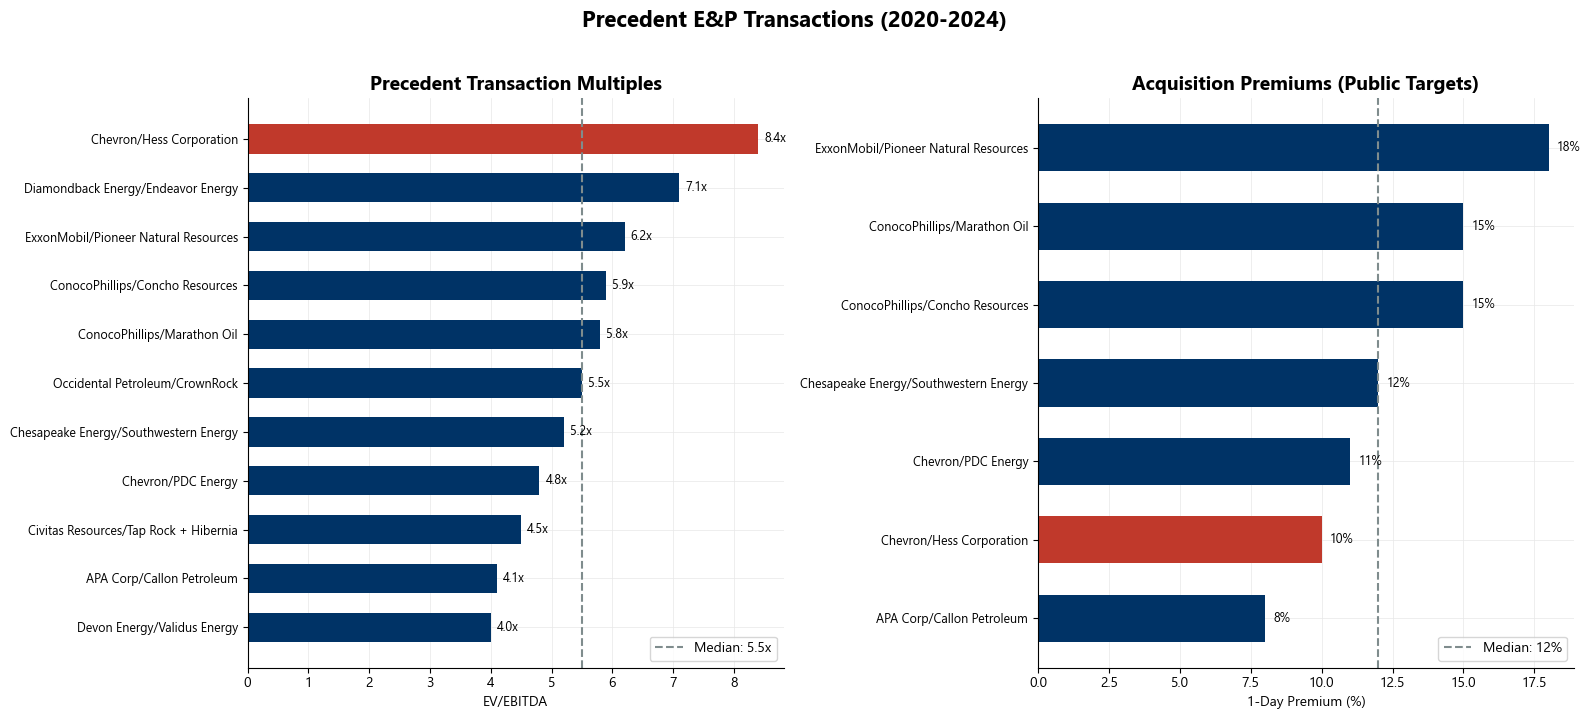

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left: EV/EBITDA by deal
sorted_prec = prec_df.sort_values('ev_ebitda')
deal_labels = [f"{r['acquirer']}/{r['target']}" for _, r in sorted_prec.iterrows()]
colors = [IB_COLORS['accent_red'] if 'Hess' in t else IB_COLORS['navy'] for t in sorted_prec['target']]
ax1.barh(range(len(sorted_prec)), sorted_prec['ev_ebitda'], color=colors, height=0.6)
ax1.set_yticks(range(len(sorted_prec)))
ax1.set_yticklabels(deal_labels, fontsize=9)
ax1.axvline(prec_df['ev_ebitda'].median(), color=IB_COLORS['gray'], linestyle='--', label=f'Median: {prec_df["ev_ebitda"].median():.1f}x')
for i, v in enumerate(sorted_prec['ev_ebitda']):
    ax1.text(v + 0.1, i, f'{v:.1f}x', va='center', fontsize=9)
ax1.set_xlabel('EV/EBITDA')
ax1.set_title('Precedent Transaction Multiples', fontweight='bold')
ax1.legend(loc='lower right')

# Right: Premium analysis (public deals only)
pub_sorted = public_deals.sort_values('premium_1day')
pub_labels = [f"{r['acquirer']}/{r['target']}" for _, r in pub_sorted.iterrows()]
pub_colors = [IB_COLORS['accent_red'] if 'Hess' in t else IB_COLORS['navy'] for t in pub_sorted['target']]
ax2.barh(range(len(pub_sorted)), pub_sorted['premium_1day'], color=pub_colors, height=0.6)
ax2.set_yticks(range(len(pub_sorted)))
ax2.set_yticklabels(pub_labels, fontsize=9)
ax2.axvline(public_deals['premium_1day'].median(), color=IB_COLORS['gray'], linestyle='--', label=f'Median: {public_deals["premium_1day"].median():.0f}%')
for i, v in enumerate(pub_sorted['premium_1day']):
    ax2.text(v + 0.3, i, f'{v:.0f}%', va='center', fontsize=9)
ax2.set_xlabel('1-Day Premium (%)')
ax2.set_title('Acquisition Premiums (Public Targets)', fontweight='bold')
ax2.legend(loc='lower right')

plt.suptitle('Precedent E&P Transactions (2020-2024)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### So What

The precedent transactions analysis provides a different lens than trading comps:

- **Control premium is real:** Precedent transactions consistently show 8-18% premiums over unaffected prices, with a median of ~12%. Chevron's 10% premium to Hess's unaffected price is at the lower end — suggesting Chevron negotiated a favorable price.
- **EV/EBITDA multiples of 4.0x-8.4x** reflect the range of asset quality and growth profiles across the E&P sector. Hess's 8.4x deal multiple is the second-highest in our universe, exceeded only by... Hess itself. This premium reflects Guyana's unique value.
- **Implied share price range:** Applying the 25th-75th percentile of precedent multiples to Hess's EBITDA yields a range that likely sits below the deal price — confirming that Chevron is paying a strategic premium for Guyana exposure.

---